In [16]:
!pip install tensorflow opencv-python matplotlib scikit-learn pillow

In [17]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [28]:
dataset_path = "dataset"

categories = ["brain_tumor","healthy"]

image_size = 128

In [29]:
dataset_path = r"C:\Users\DELL\OneDrive\Desktop\brain_tumor_detection\dataset"

In [33]:
categories = ["Healthy", "Brain Tumor"]

image_size = 128

In [34]:
print(os.listdir(dataset_path))

['Brain Tumor', 'Healthy']


In [35]:
data = []
labels = []

for category in categories:

    folder_path = os.path.join(dataset_path, category)

    label = categories.index(category)

    print("Loading:", category)

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        try:
            img = cv2.imread(img_path)

            img = cv2.resize(img, (image_size, image_size))

            data.append(img)

            labels.append(label)

        except Exception as e:
            print("Error:", img_path)

print("Dataset Loaded Successfully")

Loading: Healthy
Loading: Brain Tumor
Dataset Loaded Successfully


In [36]:
X = np.array(data)
y = np.array(labels)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (4600, 128, 128, 3)
Y Shape: (4600,)


In [37]:
X = X / 255.0

In [38]:
y = to_categorical(y, num_classes=2)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (3680, 128, 128, 3)
Testing Data: (920, 128, 128, 3)


In [40]:
model = Sequential()

# First Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(2, activation='softmax'))

In [41]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,794 (12.61 MB)

 Trainable params: 3,305,346 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [43]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [44]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    batch_size=32
)

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 54s 428ms/step - accuracy: 0.6910 - loss: 1.4231 - val_accuracy: 0.5446 - val_loss: 2.2262
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 48s 413ms/step - accuracy: 0.7859 - loss: 0.4282 - val_accuracy: 0.5370 - val_loss: 2.3445
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 47s 410ms/step - accuracy: 0.8277 - loss: 0.3473 - val_accuracy: 0.6739 - val_loss: 0.8905
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 48s 418ms/step - accuracy: 0.8766 - loss: 0.2671 - val_accuracy: 0.7196 - val_loss: 1.1257
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 48s 418ms/step - accuracy: 0.8897 - loss: 0.2519 - val_accuracy: 0.8967 - val_loss: 0.2963
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 48s 414ms/step - accuracy: 0.9060 - loss: 0.2170 - val_accuracy: 0.9174 - val_loss: 0.2059
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 49s 422ms/step - accuracy: 0.9239 - loss: 0.1839 - val_accuracy: 0.9522 - val_loss: 0.1414
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 48s 421ms/step - accuracy: 0.9470 - loss: 0

In [45]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy * 100)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.9793 - loss: 0.0580
Test Accuracy: 97.9347825050354


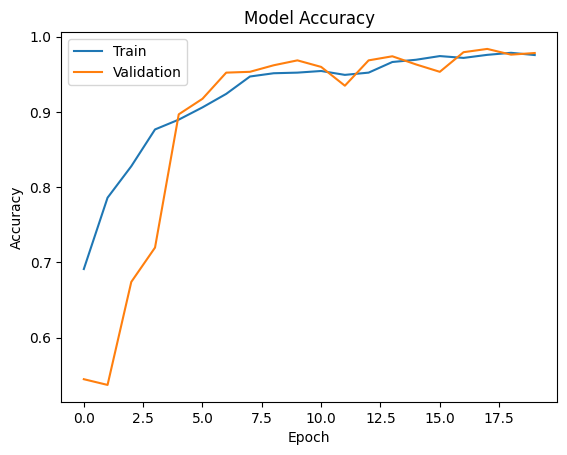

In [46]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

In [48]:
predictions = model.predict(X_test)

predictions = np.argmax(predictions, axis=1)

true_labels = np.argmax(y_test, axis=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step


In [49]:
print(classification_report(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       434
           1       0.98      0.99      0.98       486

    accuracy                           0.98       920
   macro avg       0.98      0.98      0.98       920
weighted avg       0.98      0.98      0.98       920



In [50]:
cm = confusion_matrix(true_labels, predictions)

print(cm)

[[422  12]
 [  7 479]]


In [51]:
model.save("brain_tumor_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [56]:
img_path = r"C:\Users\DELL\OneDrive\Desktop\brain_tumor_detection\dataset\Brain Tumor\Cancer (1).jpg"

In [57]:
img = cv2.imread(img_path)

img = cv2.resize(img, (128,128))

img = img / 255.0

img = np.reshape(img, [1,128,128,3])

prediction = model.predict(img)

result = np.argmax(prediction)

if result == 0:
    print("Healthy Brain")
else:
    print("Brain Tumor Detected")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Brain Tumor Detected
